# MCMC forecast for DESI DR2 BAO in flat $\Lambda$CDM

This notebook samples the **DESI DR2 BAO** likelihood with BlackJAX NUTS,
using the same BAO data products and background-theory model as
`fisher_DESI-DR2_BAO_LCDM.ipynb`.

The sampled cosmological parameters are $(\omega_b, \omega_{cdm}, h)$ with
neutrino mass fixed to $m_\nu = 0.06\,$eV.  A BBN prior on $\omega_b$ can be
enabled or disabled below.

## Imports

In [1]:
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22})

import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax.scipy.linalg import inv

from ps_1loop_jax import background as bg

from jaxptpolypol.params import CosmoParams
from jaxptpolypol.bao import load_desi_dr2, make_bao_theory_fn
from jaxptpolypol.inference import fisher_matrix, gaussian_prior_fisher
from jaxptpolypol.plotting import plot_contours, plot_Gaussian
from jaxptpolypol.sampler import (
    make_transform, make_gaussian_log_prior, make_log_posterior,
    run_nuts, samples_to_physical,
)


## Load DESI DR2 BAO data

In [2]:
bao_data_dir = "../../ext_data/bao_data/desi_bao_dr2"
bao_dr2 = load_desi_dr2("all", data_dir=bao_data_dir)

print(f"Number of data points: {len(bao_dr2.data_points)}")
print(f"Covariance shape:      {bao_dr2.cov.shape}")
print(f"rs_fid:                {bao_dr2.rs_fid}")
print()
print(f"{'z':>6s}  {'observable':>12s}  {'value':>12s}")
print("-" * 38)
for dp in bao_dr2.data_points:
    print(f"{dp.z:6.3f}  {dp.observable:>12s}  {dp.value:12.6f}")


Number of data points: 13
Covariance shape:      (13, 13)
rs_fid:                1.0

     z    observable         value
--------------------------------------
 0.295    DV_over_rs      7.941676
 0.510    DM_over_rs     13.587584
 0.510    DH_over_rs     21.862947
 0.706    DM_over_rs     17.350691
 0.706    DH_over_rs     19.455349
 0.934    DM_over_rs     21.575640
 0.934    DH_over_rs     17.641495
 1.321    DM_over_rs     27.600856
 1.321    DH_over_rs     14.176022
 1.484    DM_over_rs     30.511901
 1.484    DH_over_rs     12.817000
 2.330    DH_over_rs      8.631546
 2.330    DM_over_rs     38.988974


## Fiducial cosmology

In [3]:
# Fiducial cosmology (Planck 2018 best-fit)
cosmo_dict = {
    'ombh2': 0.02242,
    'omch2': 0.11933,
    'h':     0.6766,
}
cosmo = CosmoParams(cosmo_dict)
print(cosmo)

cosmo_keys = cosmo.param_keys
cosmo_sizes = cosmo.param_sizes
fiducial_params = cosmo.to_array()
n_varied = len(fiducial_params)

print(f"\nParameter keys:  {cosmo_keys}")
print(f"Parameter sizes: {cosmo_sizes}")
print(f"Packed array:    {fiducial_params}")


CosmoParams:
  ombh2: 0.02242
  omch2: 0.11933
  h: 0.6766

Parameter keys:  ('ombh2', 'omch2', 'h')
Parameter sizes: (1, 1, 1)
Packed array:    [0.02242 0.11933 0.6766 ]


## BAO theory and covariance

In [4]:
bao_fn = make_bao_theory_fn(
    bao_dr2,
    cosmo_keys=cosmo_keys,
    cosmo_sizes=cosmo_sizes,
    mnu_fixed=0.06,
)
jitted_bao_fn = jax.jit(bao_fn)

data = bao_dr2.data_vector
cov = bao_dr2.cov
cov_inv = inv(cov)

theory_fid = jitted_bao_fn(fiducial_params)

print(f"{'z':>6s}  {'observable':>12s}  {'data':>12s}  {'theory(fid)':>12s}  {'(th-d)/d [%]':>12s}")
print("-" * 72)
for i, dp in enumerate(bao_dr2.data_points):
    pct = 100 * (float(theory_fid[i]) - float(data[i])) / float(data[i])
    print(f"{dp.z:6.3f}  {dp.observable:>12s}  {float(data[i]):12.6f}  {float(theory_fid[i]):12.6f}  {pct:+10.3f} %")


     z    observable          data   theory(fid)  (th-d)/d [%]
------------------------------------------------------------------------
 0.295    DV_over_rs      7.941676      8.026287      +1.065 %
 0.510    DM_over_rs     13.587584     13.452675      -0.993 %
 0.510    DH_over_rs     21.862947     22.692781      +3.796 %
 0.706    DM_over_rs     17.350691     17.645969      +1.702 %
 0.706    DH_over_rs     19.455349     20.144123      +3.540 %
 0.934    DM_over_rs     21.575640     21.936343      +1.672 %
 0.934    DH_over_rs     17.641495     17.560093      -0.461 %
 1.321    DM_over_rs     27.600856     28.022939      +1.529 %
 1.321    DH_over_rs     14.176022     14.069755      -0.750 %
 1.484    DM_over_rs     30.511901     30.217927      -0.963 %
 1.484    DH_over_rs     12.817000     12.887747      +0.552 %
 2.330    DH_over_rs      8.631546      8.627777      -0.044 %
 2.330    DM_over_rs     38.988974     39.133932      +0.372 %


## Fisher matrix for whitening

In [5]:
jac = jax.jacfwd(jitted_bao_fn)(fiducial_params)
F_bao = fisher_matrix(cov, jac)

# Optional Gaussian prior: BBN on omega_b
USE_BBN_PRIOR = True
prior_entries = []
F_prior = jnp.zeros_like(F_bao)
if USE_BBN_PRIOR:
    prior_entries = [(0, 0.02218, 0.00055)]
    F_prior = gaussian_prior_fisher(n_varied, {0: 0.00055})

F_target = F_bao + F_prior
F_target_inv = inv(F_target)
fisher_sigma = jnp.sqrt(jnp.diag(F_target_inv))

print("BAO Fisher matrix:")
print(np.array(F_bao))
print()
print(f"Using BBN prior: {USE_BBN_PRIOR}")
print("Whitening scales from Fisher covariance:")
for name, sig in zip(cosmo_keys, fisher_sigma):
    print(f"  {name:>8s}: {float(sig):.6g}")


BAO Fisher matrix:
[[4614503.44095242  173251.32695733 -636763.91395722]
 [ 173251.32695733   62575.1999979   -40389.51170035]
 [-636763.91395722  -40389.51170035   92713.28497331]]

Using BBN prior: True
Whitening scales from Fisher covariance:
     ombh2: 0.00055
     omch2: 0.00488404
         h: 0.00581149


## MCMC setup: whitening, priors, log-posterior

In [6]:
# Quick-turnaround mode for laptops; switch off for longer production chains.
LAPTOP_MODE = True

if LAPTOP_MODE:
    NUM_WARMUP = 400
    NUM_SAMPLES = 1200
    NUM_CHAINS = 4
    SCAN_CHUNK = 128
    PARALLEL = True
else:
    NUM_WARMUP = 1000
    NUM_SAMPLES = 4000
    NUM_CHAINS = 4
    SCAN_CHUNK = 256
    PARALLEL = True

to_whitened, to_physical = make_transform(center=fiducial_params, scale=fisher_sigma)
log_prior = make_gaussian_log_prior(n_varied, prior_entries)
log_post = make_log_posterior(
    theory_fn=jitted_bao_fn,
    data=data,
    cov_inv=cov_inv,
    log_prior_fn=log_prior,
    to_physical=to_physical,
)

x0 = jnp.zeros(n_varied)
lp0 = log_post(x0)

print(f"Mode: {'LAPTOP' if LAPTOP_MODE else 'SERVER'}")
print(f"  warmup: {NUM_WARMUP}, samples: {NUM_SAMPLES}, chains: {NUM_CHAINS}")
print(f"  scan_chunk: {SCAN_CHUNK}, parallel_chains: {PARALLEL}")
print(f"log-posterior at fiducial point: {float(lp0):.6f}")


Mode: LAPTOP
  warmup: 400, samples: 1200, chains: 4
  scan_chunk: 128, parallel_chains: True
log-posterior at fiducial point: -11.819436


## NUTS sampling

In [7]:
%%time
rng_key = jax.random.key(42)

# Fisher inverse in whitened coordinates.
S = jnp.diag(fisher_sigma)
F_inv_whitened = S @ F_target_inv @ S
F_inv_whitened_diag = jnp.diag(F_inv_whitened)

samples_w, diagnostics = run_nuts(
    rng_key,
    log_post,
    initial_position=x0,
    num_warmup=NUM_WARMUP,
    num_samples=NUM_SAMPLES,
    num_chains=NUM_CHAINS,
    adapt_mass_matrix=True,
    mass_matrix_type="diagonal",
    initial_inverse_mass_matrix=F_inv_whitened_diag,
    scan_chunk_size=SCAN_CHUNK,
    parallel_chains=PARALLEL,
    progress_fn=lambda c, n: print(f"  warmup chain {c}/{n} done"),
)

print(f"\nSamples shape: {samples_w.shape}  (chains, samples, params)")


  warmup chain 1/4 done
  warmup chain 2/4 done
  warmup chain 3/4 done
  warmup chain 4/4 done

Samples shape: (4, 1200, 3)  (chains, samples, params)
CPU times: user 10.1 s, sys: 477 ms, total: 10.6 s
Wall time: 5.69 s


## Diagnostics

Per-chain diagnostics:
  Chain 1:  accept = 0.885   steps = 6.1   divergent = 0
  Chain 2:  accept = 0.895   steps = 6.2   divergent = 0
  Chain 3:  accept = 0.950   steps = 8.5   divergent = 0
  Chain 4:  accept = 0.930   steps = 7.7   divergent = 0


Text(0.5, 0.98, 'Trace plots (whitened space)')

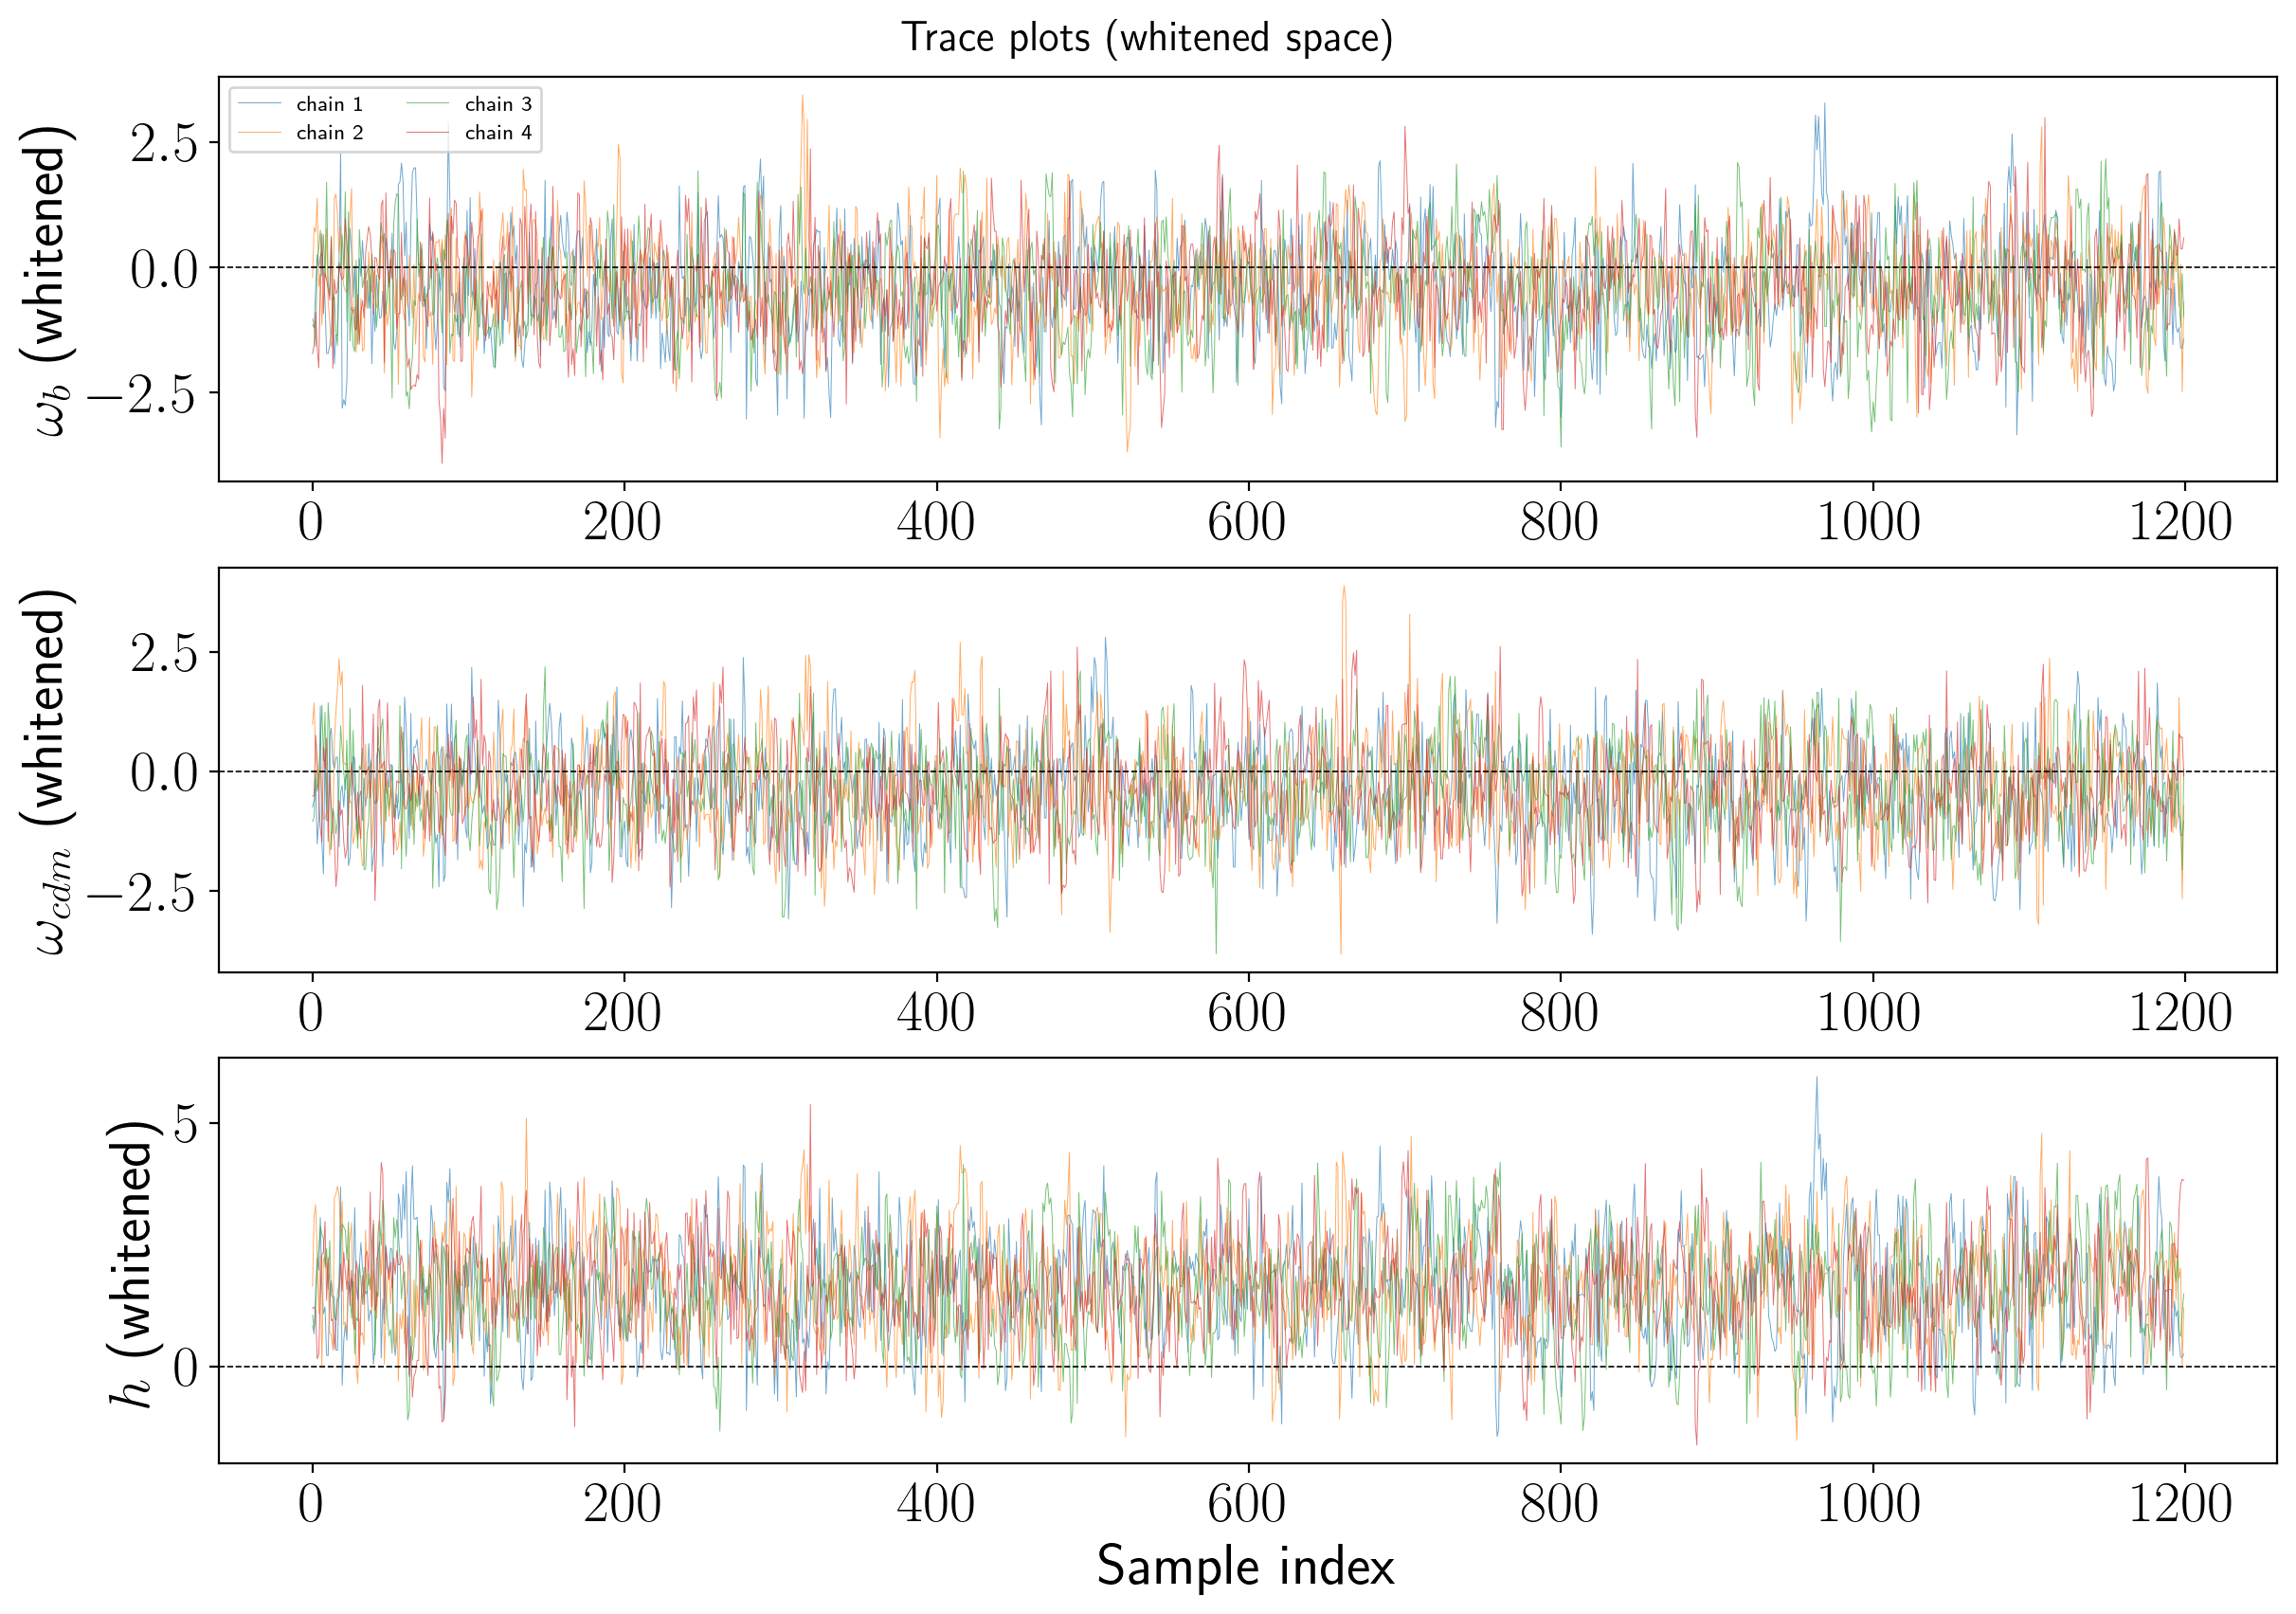

In [8]:
accept = diagnostics["acceptance_rate"]
n_steps = diagnostics["num_integration_steps"]
divergent = diagnostics["is_divergent"]

print("Per-chain diagnostics:")
for c in range(samples_w.shape[0]):
    print(
        f"  Chain {c+1}:  accept = {float(accept[c].mean()):.3f}"
        f"   steps = {float(n_steps[c].mean()):.1f}"
        f"   divergent = {int(divergent[c].sum())}"
    )

param_labels = (r'$\omega_b$', r'$\omega_{cdm}$', r'$h$')
fig, axes = plt.subplots(n_varied, 1, figsize=(12, 2.8 * n_varied), constrained_layout=True)

for i, name in enumerate(param_labels):
    ax = axes[i]
    for c in range(samples_w.shape[0]):
        ax.plot(samples_w[c, :, i], alpha=0.65, lw=0.35, label=f'chain {c+1}')
    ax.axhline(0.0, color='k', ls='--', lw=0.6)
    ax.set_ylabel(f'{name} (whitened)')
    if i == 0:
        ax.legend(fontsize=8, ncol=2)

axes[-1].set_xlabel('Sample index')
fig.suptitle('Trace plots (whitened space)', fontsize=16)


## Posterior in physical space

In [9]:
samples_phys = samples_to_physical(samples_w, to_physical)
flat_samples = samples_phys.reshape(-1, n_varied)

sample_mean = jnp.mean(flat_samples, axis=0)
sample_cov = jnp.cov(flat_samples.T)

print("Posterior summary:")
for i, name in enumerate(cosmo_keys):
    fid = float(fiducial_params[i])
    mu = float(sample_mean[i])
    sig = float(jnp.sqrt(sample_cov[i, i]))
    print(f"  {name:>8s}: fid = {fid:.6f}   mean = {mu:.6f}   std = {sig:.6f}")


Posterior summary:
     ombh2: fid = 0.022420   mean = 0.022185   std = 0.000552
     omch2: fid = 0.119330   mean = 0.117359   std = 0.004770
         h: fid = 0.676600   mean = 0.685952   std = 0.006017


## Corner plot: MCMC vs Fisher

Text(0.5, 0.98, 'MCMC (blue) vs Fisher (red dashed) — DESI DR2 BAO')

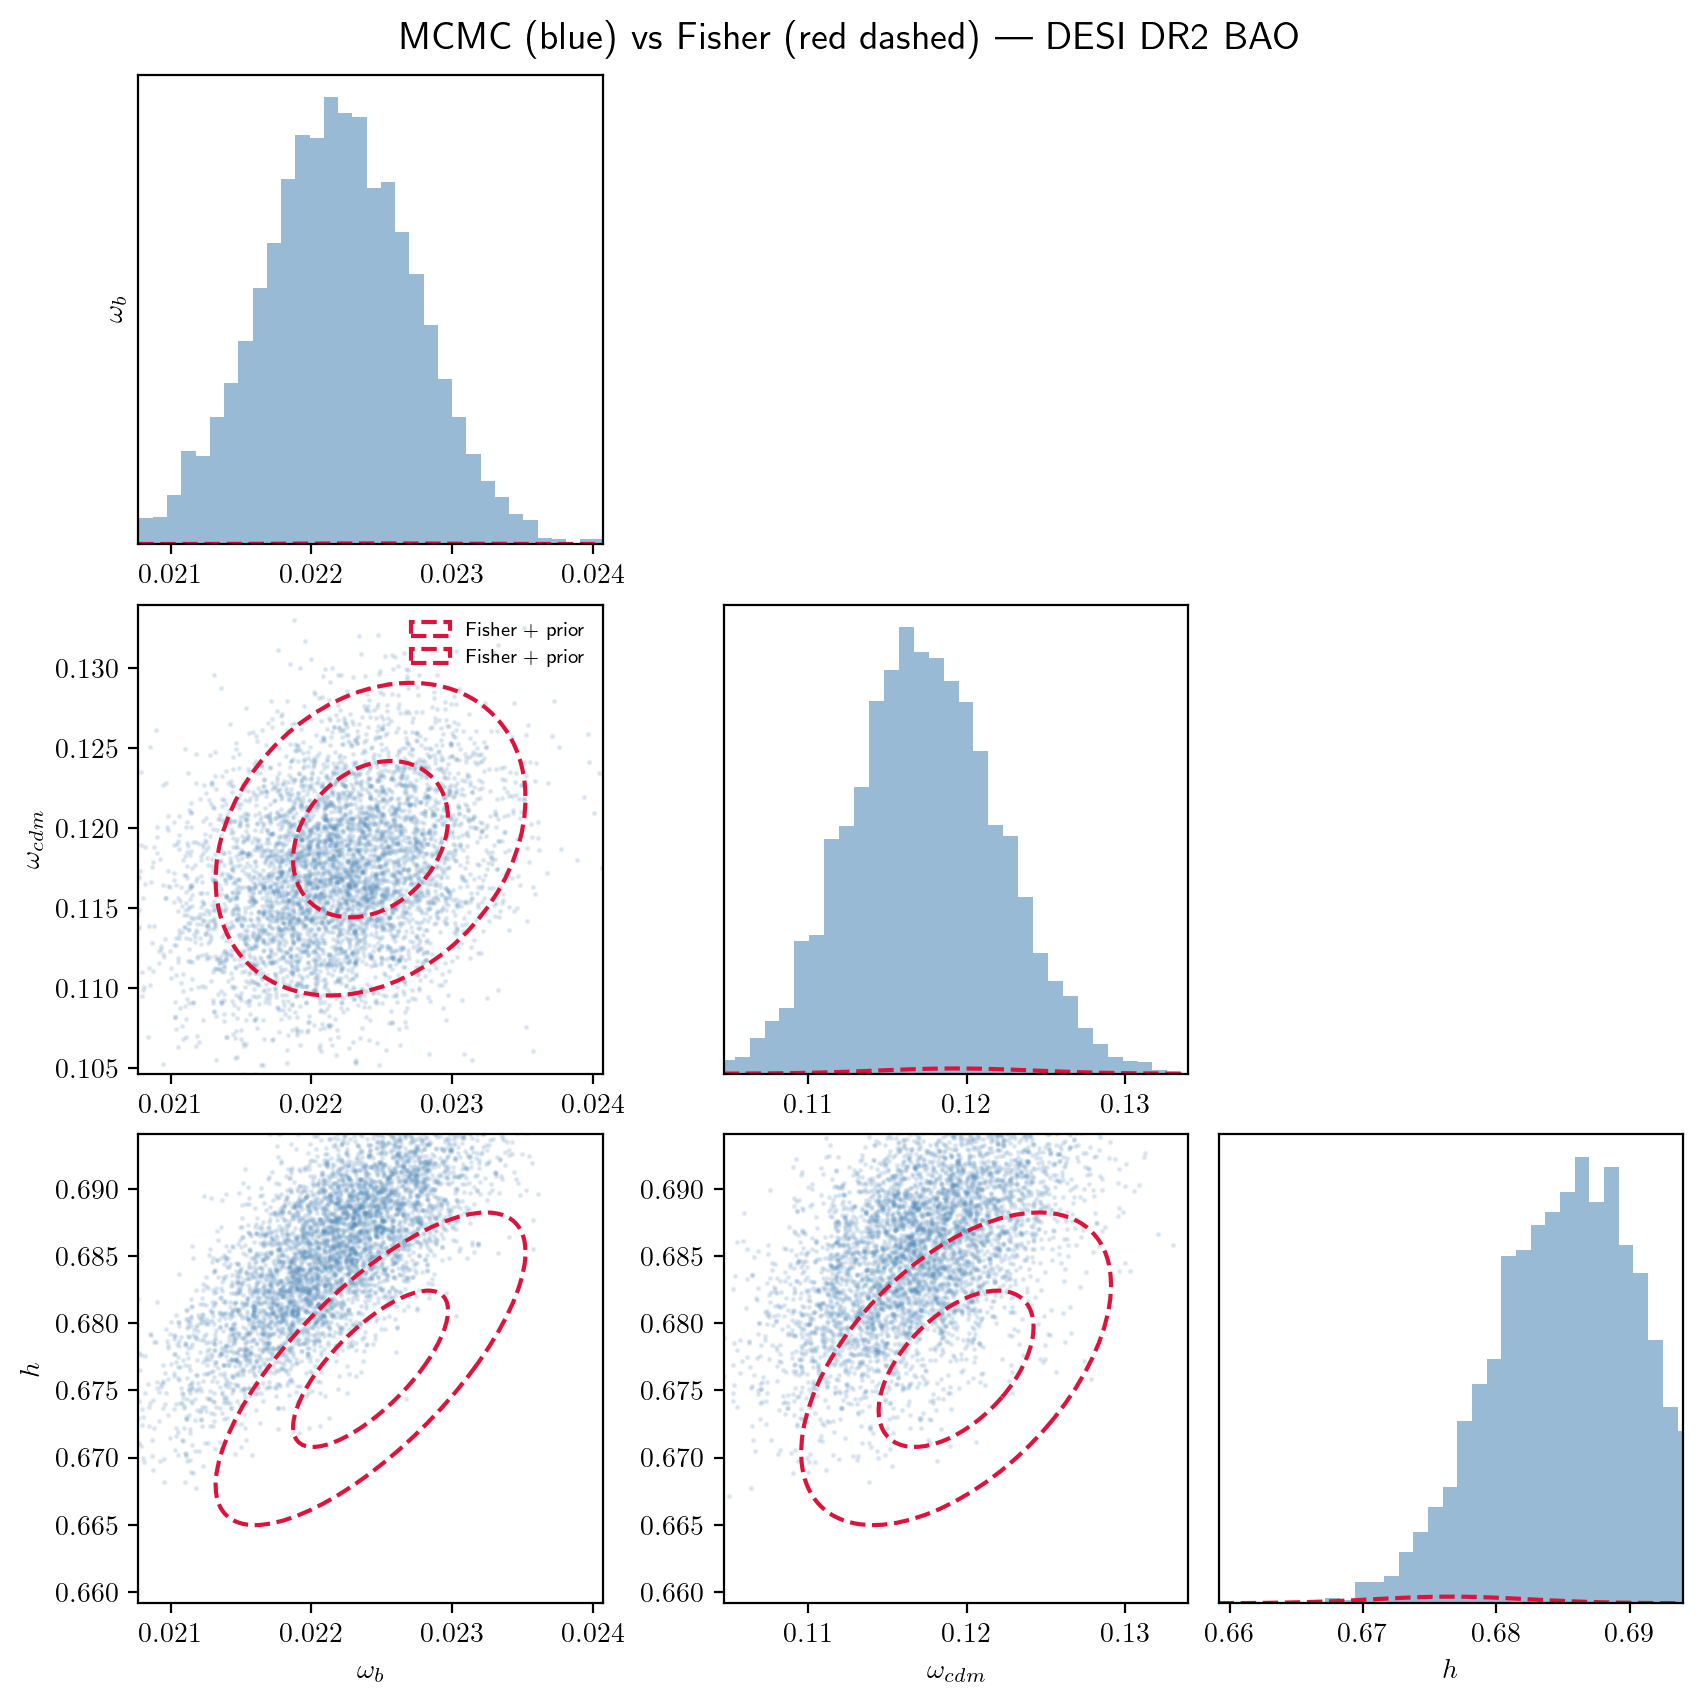

In [10]:
n_plot = len(param_labels)
fid_vals = np.array(fiducial_params)

plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(n_plot * 2.8, n_plot * 2.8), constrained_layout=True)

for i in range(n_plot):
    for j in range(n_plot):
        ax = plt.subplot(n_plot, n_plot, i * n_plot + j + 1)
        if j < i:
            ax.scatter(
                flat_samples[:, j], flat_samples[:, i],
                s=1.0, alpha=0.12, color='steelblue', rasterized=True,
            )
            plot_contours(
                F_target, fid_vals, [j, i], ax=ax,
                edgecolor='crimson', facecolor='none', ls='--', lw=1.5,
                label='Fisher + prior' if (i == 1 and j == 0) else None,
            )
            if i == 1 and j == 0:
                ax.legend(fontsize=7, frameon=False)
        elif j == i:
            ax.hist(flat_samples[:, i], bins=40, density=True,
                    color='steelblue', alpha=0.55, edgecolor='none')
            plot_Gaussian(F_target, fid_vals, i, ax=ax,
                          color='crimson', ls='--', lw=1.5)
            ax.set_yticks([])
        else:
            ax.axis('off')

        if i == n_plot - 1 and j <= i:
            ax.set_xlabel(param_labels[j])
        if j == 0 and j < i:
            ax.set_ylabel(param_labels[i])
        elif j == 0 and i == j:
            ax.set_ylabel(param_labels[i])

fig.suptitle(r'MCMC (blue) vs Fisher (red dashed) — DESI DR2 BAO', fontsize=14)


## Derived parameters and published-constraint comparison

In [11]:
def derived_Omega_m(params):
    ombh2, omch2, h = params
    return (ombh2 + omch2) / h**2

def derived_h_rd(params):
    ombh2, omch2, h = params
    rd = bg.sound_horizon_drag(ombh2, omch2, h, mnu=0.06)
    return h * rd

def derived_H0(params):
    return 100.0 * params[2]

jac_Om = jax.jacfwd(derived_Omega_m)(fiducial_params)
jac_hrd = jax.jacfwd(derived_h_rd)(fiducial_params)
jac_H0 = jax.jacfwd(derived_H0)(fiducial_params)

def fisher_sigma_derived(jac_derived):
    return float(jnp.sqrt(jac_derived @ F_target_inv @ jac_derived))

Omega_m_samples = jax.vmap(derived_Omega_m)(flat_samples)
hrd_samples = jax.vmap(derived_h_rd)(flat_samples)
H0_samples = jax.vmap(derived_H0)(flat_samples)

print(f"Using BBN prior: {USE_BBN_PRIOR}")
print()
print(f"{'Parameter':>12s}  {'Fiducial':>12s}  {'Fisher':>12s}  {'MCMC':>12s}")
print("-" * 56)
print(f"{'Omega_m':>12s}  {float(derived_Omega_m(fiducial_params)):12.5f}  {fisher_sigma_derived(jac_Om):12.5f}  {float(jnp.std(Omega_m_samples)):12.5f}")
print(f"{'h*rd [Mpc]':>12s}  {float(derived_h_rd(fiducial_params)):12.3f}  {fisher_sigma_derived(jac_hrd):12.3f}  {float(jnp.std(hrd_samples)):12.3f}")
print(f"{'H0':>12s}  {float(derived_H0(fiducial_params)):12.3f}  {fisher_sigma_derived(jac_H0):12.3f}  {float(jnp.std(H0_samples)):12.3f}")

if USE_BBN_PRIOR:
    print()
    print("Published DESI DR2 + BBN reference values (flat LCDM):")
    print("  sigma(Omega_m) = 0.0086")
    print("  sigma(H0)      = 0.58 km/s/Mpc")
else:
    print()
    print("Published DESI DR2 BAO-only reference values (flat LCDM):")
    print("  sigma(Omega_m) = 0.0086")
    print("  sigma(h*rd)    = 0.73 Mpc")


Using BBN prior: True

   Parameter      Fiducial        Fisher          MCMC
--------------------------------------------------------
     Omega_m       0.30964       0.00894       0.00838
  h*rd [Mpc]        99.585         0.723         0.718
          H0        67.660         0.581         0.602

Published DESI DR2 + BBN reference values (flat LCDM):
  sigma(Omega_m) = 0.0086
  sigma(H0)      = 0.58 km/s/Mpc


## $1\sigma$ comparison: MCMC vs Fisher

In [12]:
sigma_fisher = jnp.sqrt(jnp.diag(F_target_inv))

print(f"{'Parameter':>12s}  {'Fiducial':>10s}  {'Fisher':>10s}  {'MCMC':>10s}  {'Ratio':>8s}")
print("-" * 60)
for i, name in enumerate(param_labels):
    fid = float(fiducial_params[i])
    sf = float(sigma_fisher[i])
    sm = float(jnp.sqrt(sample_cov[i, i]))
    print(f"{name:>12s}  {fid:10.5g}  {sf:10.4g}  {sm:10.4g}  {sm / sf:8.3f}")


   Parameter    Fiducial      Fisher        MCMC     Ratio
------------------------------------------------------------
  $\omega_b$     0.02242     0.00055   0.0005522     1.004
$\omega_{cdm}$     0.11933    0.004884     0.00477     0.977
         $h$      0.6766    0.005811    0.006017     1.035
